# PPS Experiment – XDF extractor

This notebook loads a LabRecorder **.xdf** file, finds the **Audio** and **MouseEvents** streams produced by the PPS auto‑streamer, and saves them as:

* `...Audio....wav` – float32 WAV at the stream's native sample‑rate
* `...MouseClicks....csv` – a CSV with columns `rel_time_sec, x_px, y_px`

> **Tip:** if you haven't installed the required libraries in this environment yet, run the first code cell.

In [1]:
!pip install pyxdf numpy soundfile pandas --quiet
import os, pathlib, re, json
from typing import Optional

import numpy as np
import pandas as pd
import soundfile as sf
import pyxdf

In [2]:
def find_stream(streams, *, type_=None, name_regex=None, channel_count=None):
    """Return the first stream that matches all given criteria."""
    for s in streams:
        info = s['info']
        name = info['name'][0]
        stype = info['type'][0]
        nch = int(info['channel_count'][0])
        if type_ is not None and stype != type_:
            continue
        if channel_count is not None and nch != channel_count:
            continue
        if name_regex is not None and re.fullmatch(name_regex, name) is None:
            continue
        return s
    return None

In [3]:
# ---- user inputs -------------------------------------------------------
xdf_path = r"C:\Users\cogpsy-vrlab\Desktop\XDF\sub-P001_task-PPS_recording-%t_desc-%d.xdf"
out_dir  = pathlib.Path(r"C:\Users\cogpsy-vrlab\Desktop\XDF")   # <─ fixed output folder
# -----------------------------------------------------------------------

out_dir.mkdir(parents=True, exist_ok=True)

print(f"Loading {xdf_path} ...")
streams, _ = pyxdf.load_xdf(xdf_path)
print(f"Loaded {len(streams)} streams")

# Identify audio stream (2 channels, type 'Audio')
audio_stream = (
    find_stream(streams, type_="Audio", channel_count=2)
    or find_stream(streams, name_regex=r".*_Audio_.*")
)

# Identify mouse‑click stream (3 channels, type 'MouseEvents')
mouse_stream = (
    find_stream(streams, type_="MouseEvents", channel_count=3)
    or find_stream(streams, name_regex=r".*_MouseClicks_.*")
)

print("\n--- streams detected ---")
print("Audio:", audio_stream['info']['name'][0] if audio_stream else "not found")
print("Mouse:", mouse_stream['info']['name'][0] if mouse_stream else "not found")

Loading C:\Users\cogpsy-vrlab\Desktop\XDF\sub-P001_task-PPS_recording-%t_desc-%d.xdf ...
Loaded 2 streams

--- streams detected ---
Audio: PPS_Unknown_Audio_20250429_180700
Mouse: PPS_Unknown_MouseClicks_20250429_180700


In [4]:
# ---- save audio --------------------------------------------------------
if audio_stream:
    name = audio_stream["info"]["name"][0]
    sr   = int(float(audio_stream["info"]["nominal_srate"][0]))   # e.g. "44100.0000"

    ts = audio_stream["time_series"]           # alias for readability
    if len(ts) == 0:                           # <─ robust emptiness check
        print(f"⚠️  Stream '{name}' contains 0 samples – nothing to write.")
    else:
        samples = np.vstack(ts).astype(np.float32).clip(-1.0, 1.0)
        wav_path = out_dir / f"{name}.wav"
        sf.write(wav_path, samples, sr)
        print(f"✓ Saved audio -> {wav_path}   shape={samples.shape}, sr={sr}")
else:
    print("No audio stream found")


✓ Saved audio -> C:\Users\cogpsy-vrlab\Desktop\XDF\PPS_Unknown_Audio_20250429_180700.wav   shape=(2228224, 2), sr=44100


In [5]:
# ---- save mouse clicks -------------------------------------------------
if mouse_stream:
    name = mouse_stream['info']['name'][0]
    click_data = np.array(mouse_stream['time_series'], dtype=np.float64)
    df_clicks = pd.DataFrame(click_data, columns=['rel_time_sec', 'x_px', 'y_px'])
    csv_path = out_dir / f"{name}.csv"
    df_clicks.to_csv(csv_path, index=False)
    print(f"Saved mouse clicks -> {csv_path}  rows={len(df_clicks)}")
else:
    print("No mouse stream to save")

Saved mouse clicks -> C:\Users\cogpsy-vrlab\Desktop\XDF\PPS_Unknown_MouseClicks_20250429_180700.csv  rows=99


Loading sub-P001_task-PPS_recording-%t_desc-%d.xdf


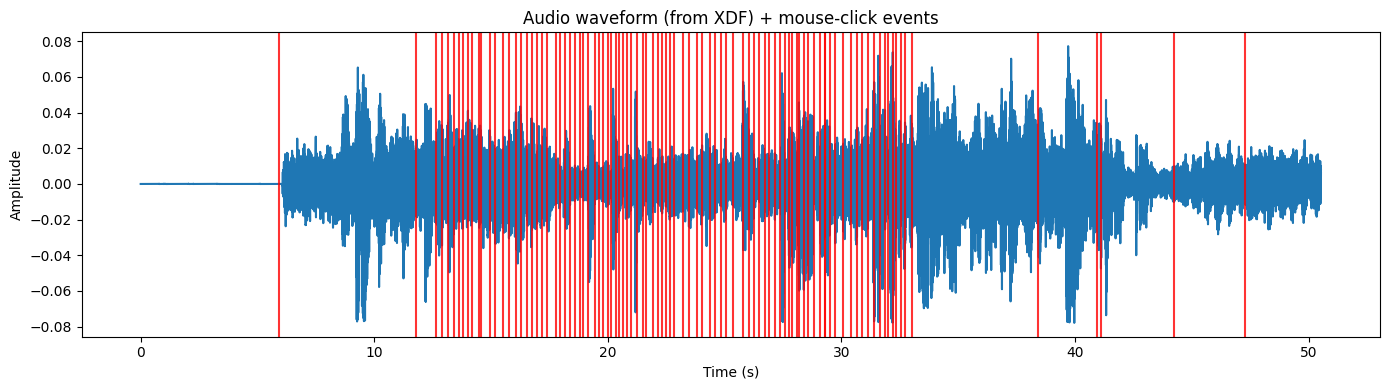

✓ All clicks lie within the audio recording window.


In [9]:
# --- perfectly aligned audio + click plot ------------------------------------
import pathlib, numpy as np, pandas as pd, pyxdf, matplotlib.pyplot as plt

# ⇩  Point to the XDF you just recorded  (here: newest file in the folder)
xdf_dir  = pathlib.Path(r"C:\Users\cogpsy-vrlab\Desktop\XDF")
xdf_path = max(xdf_dir.glob("*.xdf"), key=lambda p: p.stat().st_mtime)

print("Loading", xdf_path.name)
streams, _ = pyxdf.load_xdf(xdf_path)

# ---- pick the audio + mouse streams ----
audio = next(s for s in streams if s["info"]["type"][0] == "Audio")
mouse = next(s for s in streams if s["info"]["type"][0] == "MouseEvents")

# audio data + timestamps
aud_data  = np.vstack(audio["time_series"]).astype(np.float32)       # (N, ch)
aud_ts    = np.asarray(audio["time_stamps"])                         # (N,)
aud_mono  = aud_data.mean(axis=1)                                    # mono
t0        = aud_ts[0]                                                # common zero

# mouse click timestamps (already relative to stream start in your code,
# but we read the absolute LSL ts here to guarantee sync)
click_ts  = np.asarray(mouse["time_stamps"]) - t0

# ---- plot ----
plt.figure(figsize=(14,4))
plt.plot(aud_ts - t0, aud_mono, label="audio (mono)")
for t in click_ts:
    plt.axvline(t, color="red", alpha=0.8)
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.title("Audio waveform (from XDF) + mouse-click events")
plt.tight_layout(); plt.show()

# ---- quick sanity check: any clicks after audio stopped? --------------------
extra = click_ts[ click_ts > (aud_ts[-1] - t0) ]
if extra.size:
    print(f"⚠️  {len(extra)} click(s) occur AFTER the last audio sample "
          f"({aud_ts[-1]-t0:.2f}s). "
          "Probably recorded while audio stream had already stopped.")
else:
    print("✓ All clicks lie within the audio recording window.")
